In [1]:
import numpy as np
import cantera as ct

In [4]:
inj_state = np.load(r'C:\GIT_Fork\ROMify\examples\1D_RDE\Injection_Files\h2o2ar_phi_1_10ms_1atm_inject_prim_state.npy')
print(inj_state)

[[2.56470983e+00]
 [1.00000000e+01]
 [1.01325000e+05]
 [3.00000000e+02]
 [1.27724300e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.01362140e-01]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [8.85865430e-01]
 [0.00000000e+00]]


In [6]:
gas = ct.Solution('h2o2.yaml')
gas.TPY = inj_state[3,0], inj_state[2,0], inj_state[4:,0]

In [ ]:
gamma = gas.cp_mass/gas.cv_mass
C     = gas.sound_speed

In [ ]:
alpha = HR * inj_state[0,0] / inj_state[0,0]

M_cj  = np.sqrt(1 + (alpha*(gamma**2 - 1)/2/gamma)) + np.sqrt(alpha*(gamma**2 - 1)/2/gamma)

-1.0732062207599814e-26


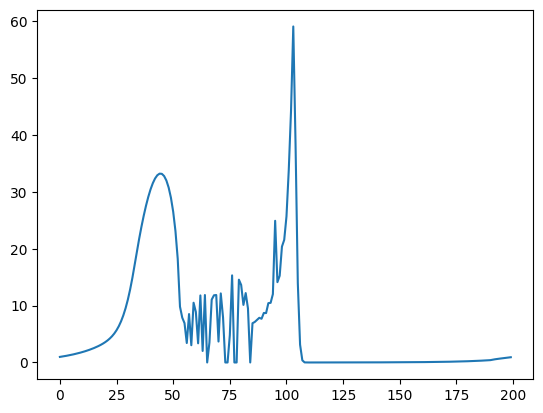

In [33]:
import numpy as np
import cantera as ct
import matplotlib.pyplot as plt

prim = np.load(r'C:\GIT_Fork\ROMify\examples\1D_RDE\FOM_results\19000iteration_prim.npy')

rho=prim[0]
P  = prim[2]
T  = prim[3]
MF = prim[4:-1]
MF_last_row = 1.0 - np.sum(MF, axis=0)
MF_full = np.vstack((MF, MF_last_row))
MF_full[MF_full == 0] = 1e-30
MF_reshaped = MF_full.T[np.newaxis, :, :]

gas = ct.Solution('h2o2.yaml')
gas_arr = ct.SolutionArray(gas,(1,200))

gas_arr.TPY = T, P, MF_reshaped

vol = 0.0288/200

mass = rho * vol

c     = np.squeeze(gas_arr.sound_speed)
gamma = np.squeeze(gas_arr.cp)/np.squeeze(gas_arr.cv)
HR    = np.squeeze(gas_arr.heat_release_rate) * vol * 1e-9 / mass
HR[HR<0] = 0

V_cj  = np.sqrt(2 * (gamma**2 - 1) * HR )
M_cj  = V_cj / c


plt.plot(V_cj)
plt.show()

